### Wczytywanie danych

In [1]:
import pandas as pd

with open('normal_small.xlsx', 'rb') as file:
    data = pd.read_excel(file)

df = pd.DataFrame(data)
df.columns = ['Time', 'Voltage [mV]']
df.index = df.index + 1
df.head()


,Time,Voltage [mV]
1,0.003995,-0.449
2,0.007989,-0.435
3,0.011984,-0.392
4,0.015979,-0.394
5,0.019973,-0.376


In [2]:
# Wyliczenie fs
delta_t = df["Time"].diff().mean()
fs = 1 / delta_t
print(f"Częstotliwość próbkowania wynosi: {round(fs, 0)} [Hz]")

Częstotliwość próbkowania wynosi: 250.0 [Hz]


### Analiza częstotliwości składowych (FFT)

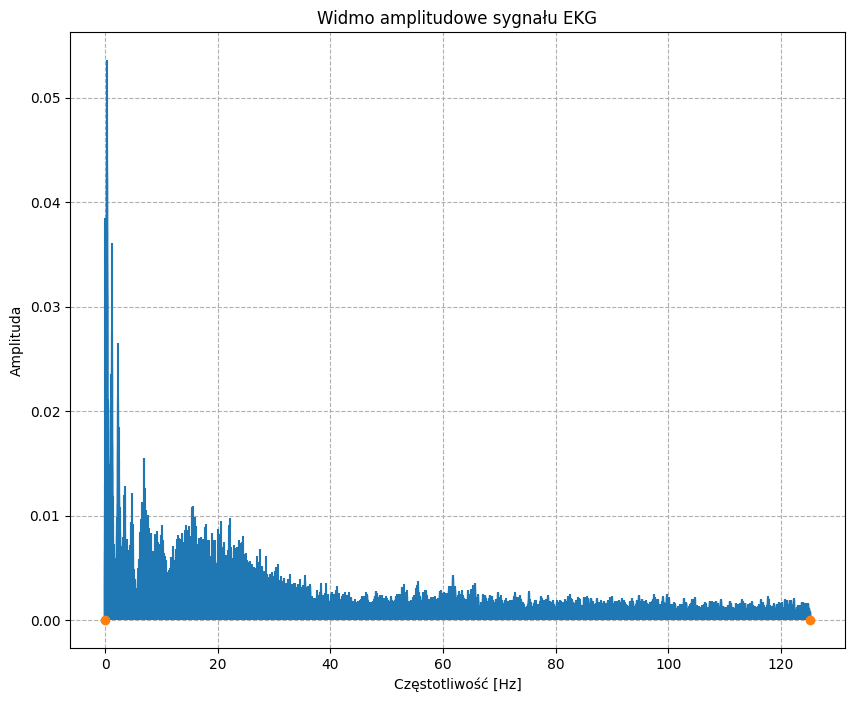

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

signal = df["Voltage [mV]"].values
n = len(signal)

fft_values = np.fft.fft(signal)
freq = np.fft.fftfreq(n, d=delta_t)
amplitude = np.abs(fft_values) * (2.0 / n)

plt.figure(figsize=(10, 8))
plt.stem(freq[:n//2], amplitude[:n//2], linefmt='-', markerfmt=' ', basefmt=' ')
plt.title('Widmo amplitudowe sygnału EKG')
plt.xlabel('Częstotliwość [Hz]')
plt.ylabel('Amplituda')
plt.grid(linestyle='--')

### Preprocesing

In [4]:
# Filtracja

(50.5, 51.5)

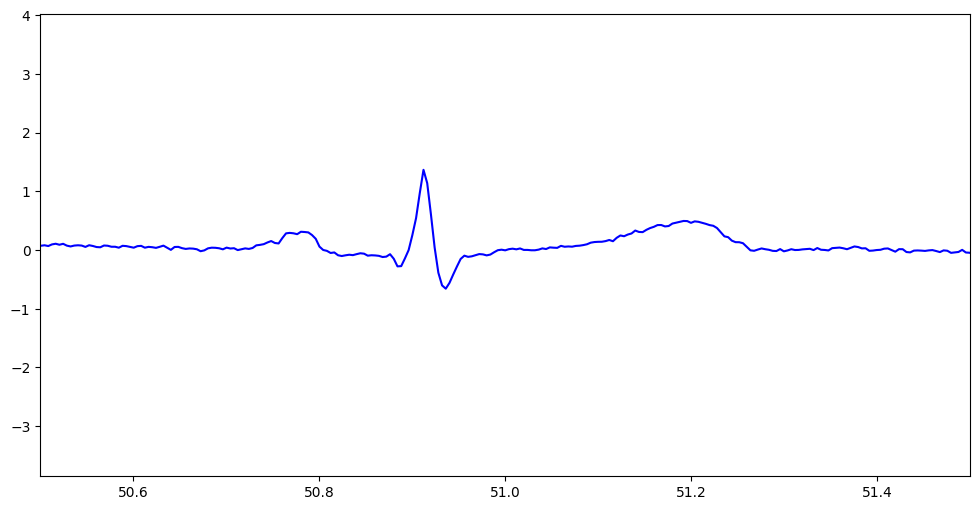

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Time'], df['Voltage [mV]'], color='blue')
plt.xlim(50.5, 51.5)